In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Paths (edit if your folder name differs) ----
RESULTS_DIR = os.path.join("..", "results", "topology_sweep")
TS_AGG_PATH = os.path.join(RESULTS_DIR, "timeseries_agg.csv")
SUMMARY_PATH = os.path.join(RESULTS_DIR, "summary_table.csv")

df_ts = pd.read_csv(TS_AGG_PATH)
df_sum = pd.read_csv(SUMMARY_PATH)

df_ts.head(), df_sum.head()

(  graph_type    params  t  gini_mean  gini_std  pov_mean  pov_std
 0         ba  {"m": 3}  0   0.000497  0.000000       0.0      0.0
 1         ba  {"m": 3}  1   0.000970  0.000098       0.0      0.0
 2         ba  {"m": 3}  2   0.001439  0.000134       0.0      0.0
 3         ba  {"m": 3}  3   0.001913  0.000147       0.0      0.0
 4         ba  {"m": 3}  4   0.002383  0.000158       0.0      0.0,
   graph_type                                             params  \
 0         ba                                           {"m": 3}   
 1         er                                        {"p": 0.04}   
 2        sbm  {"p_in": 0.1, "p_out": 0.005, "sizes": [50, 50...   
 3         ws                          {"k": 8, "p_rewire": 0.1}   
 
    escape_fraction_mean  escape_time_mean  gini_final_mean  \
 0                   NaN               NaN         0.059937   
 1                   NaN               NaN         0.061741   
 2                   NaN               NaN         0.061052   
 3 

In [3]:
# Map internal graph type codes to nicer labels for the thesis
LABELS = {
    "er": "Erdős–Rényi (ER)",
    "ws": "Watts–Strogatz (WS)",
    "ba": "Barabási–Albert (BA)",
    "sbm": "Stochastic Block Model (SBM)"
}

ORDER = ["er", "ws", "ba", "sbm"]
present = [g for g in ORDER if g in df_ts["graph_type"].unique()]
present

['er', 'ws', 'ba', 'sbm']

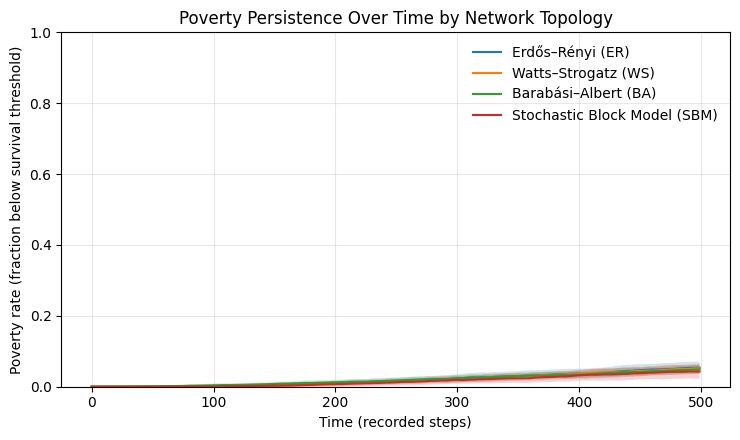

'../results/topology_sweep/fig_poverty_rate_over_time.png'

In [4]:
fig = plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

for g in present:
    sub = df_ts[df_ts["graph_type"] == g].sort_values("t")
    x = sub["t"].to_numpy()
    y = sub["pov_mean"].to_numpy()
    s = sub["pov_std"].to_numpy()

    ax.plot(x, y, label=LABELS.get(g, g))
    # shading for variability across runs
    ax.fill_between(x, y - s, y + s, alpha=0.2)

ax.set_xlabel("Time (recorded steps)")
ax.set_ylabel("Poverty rate (fraction below survival threshold)")
ax.set_title("Poverty Persistence Over Time by Network Topology")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# Save
out_png = os.path.join(RESULTS_DIR, "fig_poverty_rate_over_time.png")
out_pdf = os.path.join(RESULTS_DIR, "fig_poverty_rate_over_time.pdf")
fig.tight_layout()
fig.savefig(out_png, dpi=300)
fig.savefig(out_pdf)
plt.show()

out_png

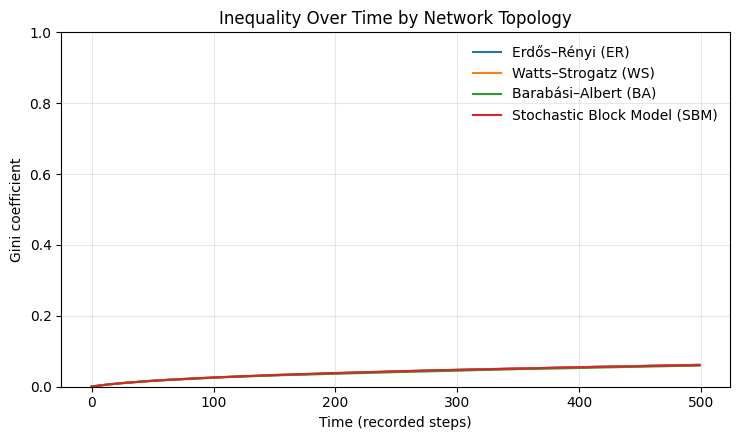

'../results/topology_sweep/fig_gini_over_time.png'

In [5]:
fig = plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

for g in present:
    sub = df_ts[df_ts["graph_type"] == g].sort_values("t")
    x = sub["t"].to_numpy()
    y = sub["gini_mean"].to_numpy()
    s = sub["gini_std"].to_numpy()

    ax.plot(x, y, label=LABELS.get(g, g))
    ax.fill_between(x, y - s, y + s, alpha=0.2)

ax.set_xlabel("Time (recorded steps)")
ax.set_ylabel("Gini coefficient")
ax.set_title("Inequality Over Time by Network Topology")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# Save
out_png = os.path.join(RESULTS_DIR, "fig_gini_over_time.png")
out_pdf = os.path.join(RESULTS_DIR, "fig_gini_over_time.pdf")
fig.tight_layout()
fig.savefig(out_png, dpi=300)
fig.savefig(out_pdf)
plt.show()

out_png

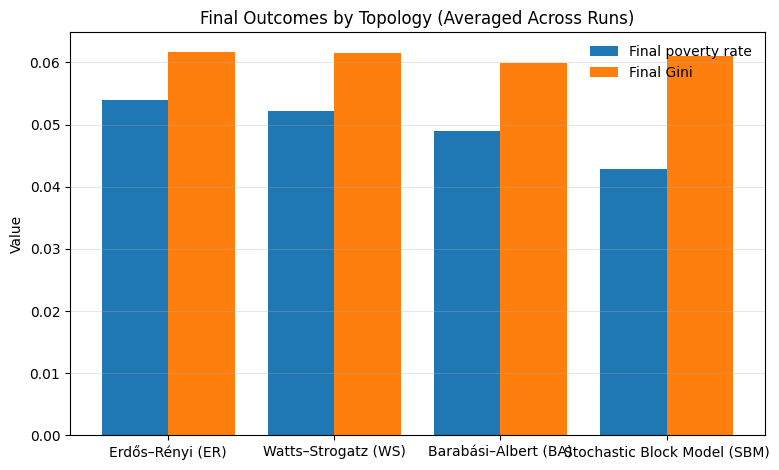

'../results/topology_sweep/fig_summary_final_outcomes.png'

In [6]:
# Build a cleaner summary table
df_plot = df_sum.copy()
df_plot["Topology"] = df_plot["graph_type"].map(lambda x: LABELS.get(x, x))

# If you have multiple params per topology, keep them separate by adding params into the label
# (If only one per topology, this is fine as-is)
if "params" in df_plot.columns and df_plot["params"].nunique() > len(df_plot["graph_type"].unique()):
    df_plot["Topology"] = df_plot["Topology"] + "\n" + df_plot["params"]

# Sort in a stable way
df_plot["order_key"] = df_plot["graph_type"].apply(lambda x: ORDER.index(x) if x in ORDER else 999)
df_plot = df_plot.sort_values("order_key")

# Plot 2 bars side-by-side using separate axes (clean and readable)
fig = plt.figure(figsize=(8, 4.8))
ax = plt.gca()

x = np.arange(len(df_plot))
width = 0.4

ax.bar(x - width/2, df_plot["poverty_final_mean"], width, label="Final poverty rate")
ax.bar(x + width/2, df_plot["gini_final_mean"], width, label="Final Gini")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["Topology"], rotation=0)
ax.set_ylabel("Value")
ax.set_title("Final Outcomes by Topology (Averaged Across Runs)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False)

out_png = os.path.join(RESULTS_DIR, "fig_summary_final_outcomes.png")
out_pdf = os.path.join(RESULTS_DIR, "fig_summary_final_outcomes.pdf")
fig.tight_layout()
fig.savefig(out_png, dpi=300)
fig.savefig(out_pdf)
plt.show()

out_png

In [7]:
# Keep only the most thesis-relevant columns
cols = [
    "graph_type", "params",
    "escape_fraction_mean", "escape_time_mean",
    "poverty_final_mean", "gini_final_mean",
    "spearman_rank_corr_mean", "mean_abs_rank_change_mean"
]
cols = [c for c in cols if c in df_sum.columns]
df_display = df_sum[cols].copy()

df_display["graph_type"] = df_display["graph_type"].map(lambda x: LABELS.get(x, x))
df_display

,graph_type,params,escape_fraction_mean,escape_time_mean,poverty_final_mean,gini_final_mean,spearman_rank_corr_mean,mean_abs_rank_change_mean
0,Barabási–Albert (BA),"{""m"": 3}",NaN,NaN,0.048900,0.059937,0.033387,64.486200
1,Erdős–Rényi (ER),"{""p"": 0.04}",NaN,NaN,0.054013,0.061741,0.034388,64.684489
2,Stochastic Block Model (SBM),"{""p_in"": 0.1, ""p_out"": 0.005, ""sizes"": [50, 50...",NaN,NaN,0.042863,0.061052,0.015683,65.315430
3,Watts–Strogatz (WS),"{""k"": 8, ""p_rewire"": 0.1}",NaN,NaN,0.052200,0.061541,0.025227,64.875000
